In [1]:
# Step 1: Load Dataset & Description

import pandas as pd

# Load the dataset
diet = pd.read_csv(r"C:\Users\gbroc\Documents\ML\daily_food_nutrition_dataset.csv")

# Display basic info
print("Dataset Shape:")
diet.head()


Dataset Shape:


,Date,User_ID,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,2024-09-11,496,Eggs,Meat,173,42.4,83.7,1.5,1.5,12.7,752,125,Lunch,478
1,2024-12-17,201,Apple,Fruits,66,39.2,13.8,3.2,2.6,12.2,680,97,Lunch,466
2,2024-06-09,776,Chicken Breast,Meat,226,27.1,79.1,25.8,3.2,44.7,295,157,Breakfast,635
3,2024-08-27,112,Banana,Fruits,116,43.4,47.1,16.1,6.5,44.1,307,13,Snack,379
4,2024-07-28,622,Banana,Fruits,500,33.9,75.8,47.0,7.8,19.4,358,148,Lunch,471


In [2]:
#Checking if there is any missing values and removing
print("Before removing missing values:",diet.shape)
print("No of missing values in the dataset:\n",diet.head().isnull().sum())
diet=diet.dropna()
print("After removing missing values:",diet.shape)

Before removing missing values: (10000, 14)
No of missing values in the dataset:
 Date                 0
User_ID              0
Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64
After removing missing values: (10000, 14)


In [3]:
#Feature construction


# Create Macro Nutrient Ratios
diet["Protein_Ratio"] = diet["Protein (g)"] / (diet["Protein (g)"] + diet["Carbohydrates (g)"] + diet["Fat (g)"])
diet["Carb_Ratio"]    = diet["Carbohydrates (g)"] / (diet["Protein (g)"] + diet["Carbohydrates (g)"] + diet["Fat (g)"])
diet["Fat_Ratio"]     = diet["Fat (g)"] / (diet["Protein (g)"] + diet["Carbohydrates (g)"] + diet["Fat (g)"])

# Add New Feature: Diet_Label
def assign_diet_label(row):
    if row["Carb_Ratio"] < 0.15 and row["Fat_Ratio"] > 0.6:
        return "Keto"
    elif row["Protein_Ratio"] > 0.25:
        return "High-Protein"
    elif 0.45 <= row["Carb_Ratio"] <= 0.65 and 0.15 <= row["Protein_Ratio"] <= 0.25:
        return "Balanced"
    else:
        return "High-Carb"

diet["Diet_Type"] = diet.apply(assign_diet_label, axis=1)

print("After constructing new features:")
print(diet.head())

After constructing new features:
         Date  User_ID       Food_Item Category  Calories (kcal)  Protein (g)  \
0  2024-09-11      496            Eggs     Meat              173         42.4   
1  2024-12-17      201           Apple   Fruits               66         39.2   
2  2024-06-09      776  Chicken Breast     Meat              226         27.1   
3  2024-08-27      112          Banana   Fruits              116         43.4   
4  2024-07-28      622          Banana   Fruits              500         33.9   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0               83.7      1.5        1.5        12.7          752   
1               13.8      3.2        2.6        12.2          680   
2               79.1     25.8        3.2        44.7          295   
3               47.1     16.1        6.5        44.1          307   
4               75.8     47.0        7.8        19.4          358   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  Protein_Ratio 

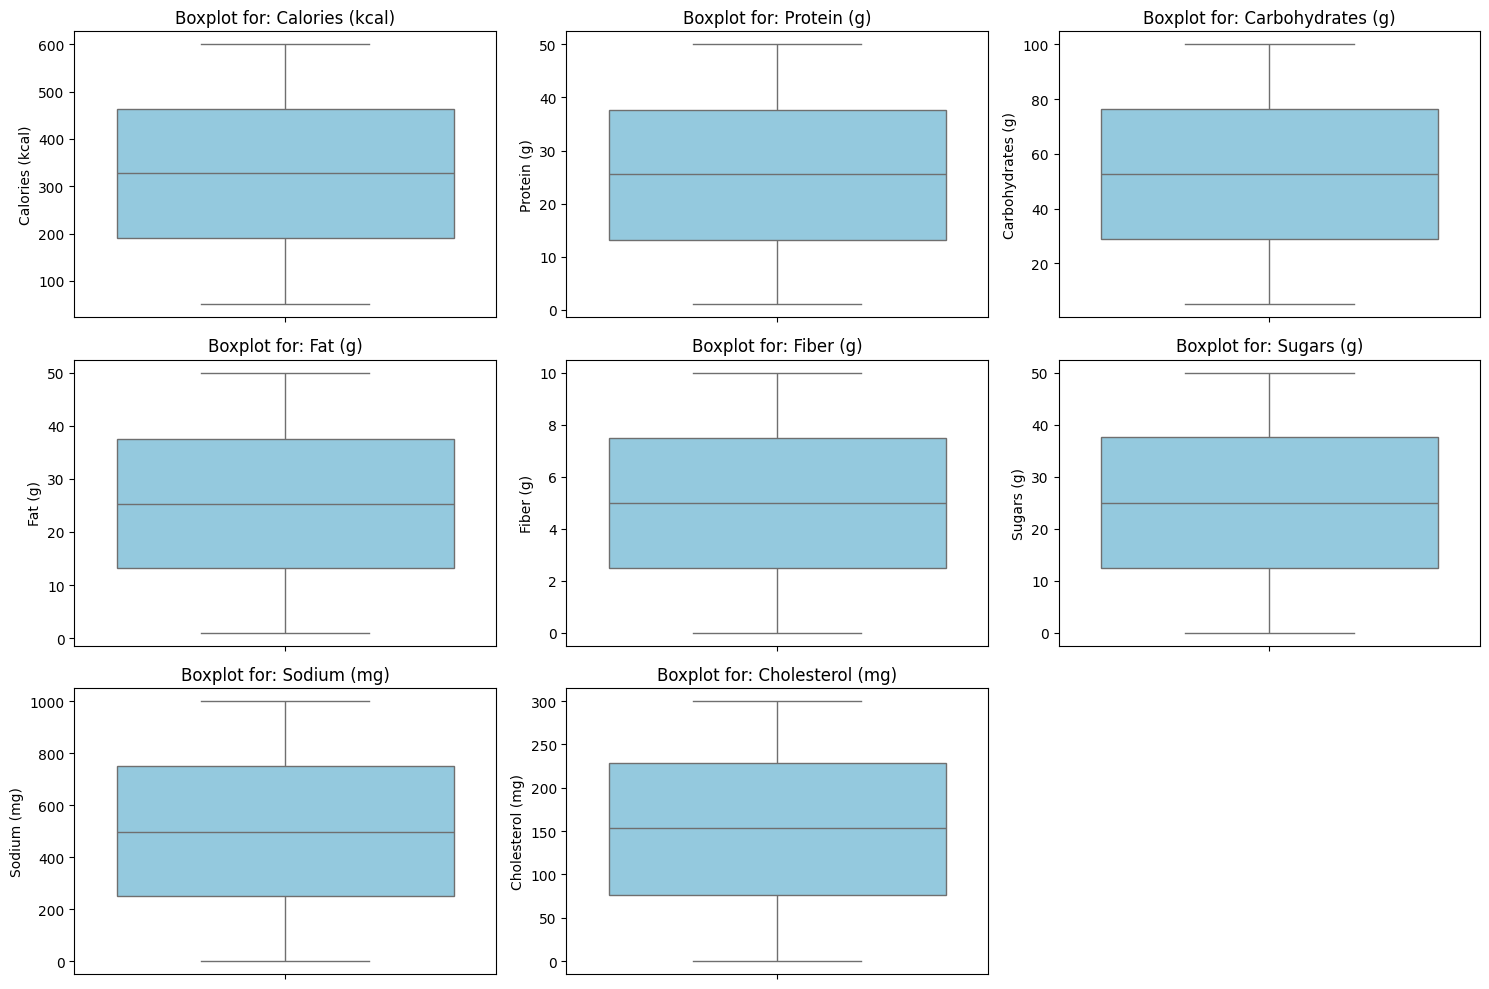

In [4]:
#Outlier Analysis
#Selecting only numeric features for outlier analysis
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)", 
                    "Fat (g)", "Fiber (g)", "Sugars (g)", "Sodium (mg)", "Cholesterol (mg)"]

# Plot boxplots for each numeric feature
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)   # 3 rows x 3 cols grid
    sns.boxplot(y=diet[col], color="skyblue")
    plt.title(f"Boxplot for: {col}")

plt.tight_layout()
plt.show()


In [6]:
#Outlier Removal
# Using IQR method to remove outliers from numeric features

Q1 = diet[numeric_features].quantile(0.25)
Q3 = diet[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Filtering dataset
diet_clean = diet[~((diet[numeric_features] < (Q1 - 1.5 * IQR)) | 
                    (diet[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape before outlier removal:", diet.shape)
print("Shape after outlier removal:", diet_clean.shape)


Shape before outlier removal: (10000, 18)
Shape after outlier removal: (10000, 18)


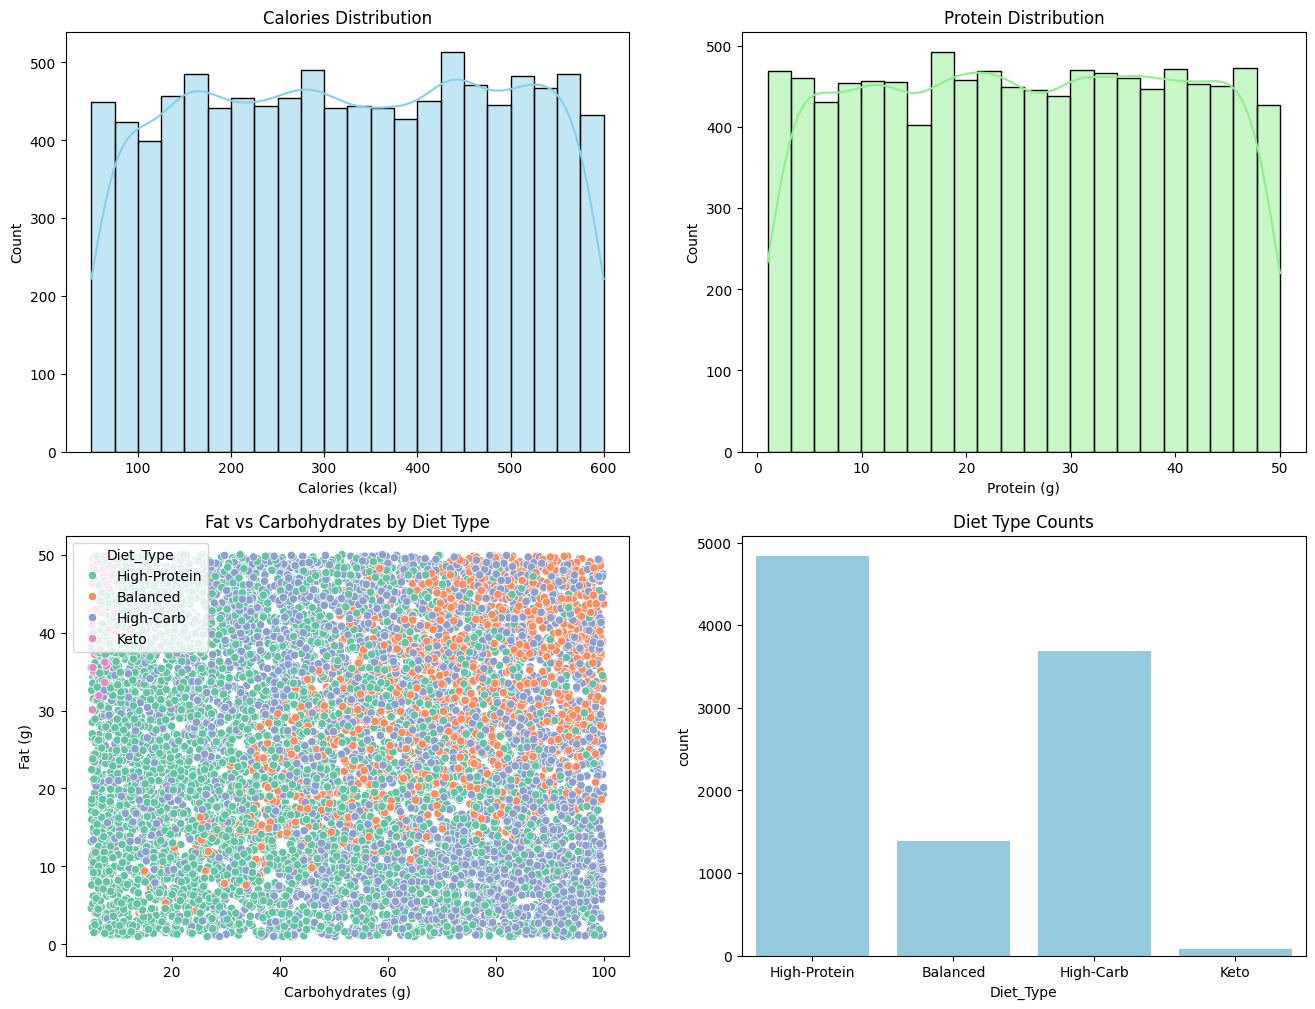

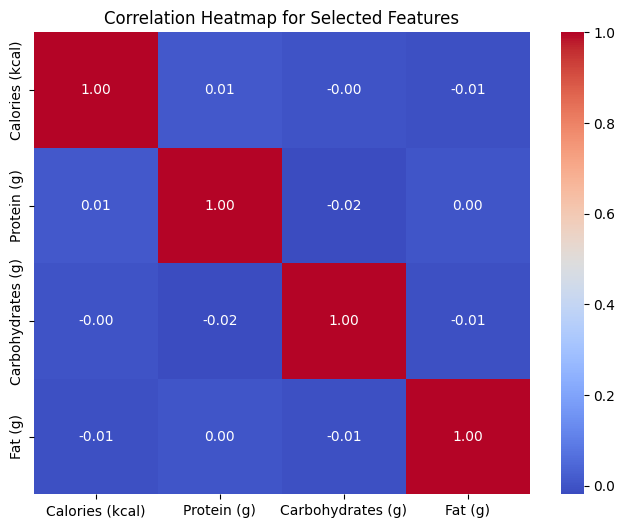

In [7]:
#Understanding Data (using EDA Visualizations)
plt.figure(figsize=(16,12))

# Calories distribution
plt.subplot(2,2,1)
sns.histplot(diet['Calories (kcal)'], kde=True, color='skyblue')
plt.title("Calories Distribution")

# Protein distribution
plt.subplot(2,2,2)
sns.histplot(diet['Protein (g)'], kde=True, color='lightgreen')
plt.title("Protein Distribution")

# Fat vs Carbohydrates scatter plot
plt.subplot(2,2,3)
sns.scatterplot(x='Carbohydrates (g)', y='Fat (g)', hue='Diet_Type', data=diet_clean, palette='Set2')
plt.title("Fat vs Carbohydrates by Diet Type")

#Diet Type count plot 
plt.subplot(2,2,4)
sns.countplot(x='Diet_Type', data=diet_clean, color='skyblue')
plt.title("Diet Type Counts")

# Correlation Heatmap for selected numeric features
selected_features = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)", "Fat (g)"]

plt.figure(figsize=(8,6))
sns.heatmap(diet[selected_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Selected Features")
plt.show()


In [8]:
#Normalization using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
diet = diet_clean.copy()
diet[numeric_features] = scaler.fit_transform(diet_clean[numeric_features])

print("Dataset after normalization:")
print(diet.head())


Dataset after normalization:
         Date  User_ID       Food_Item Category  Calories (kcal)  Protein (g)  \
0  2024-09-11      496            Eggs     Meat         0.223636     0.844898   
1  2024-12-17      201           Apple   Fruits         0.029091     0.779592   
2  2024-06-09      776  Chicken Breast     Meat         0.320000     0.532653   
3  2024-08-27      112          Banana   Fruits         0.120000     0.865306   
4  2024-07-28      622          Banana   Fruits         0.818182     0.671429   

   Carbohydrates (g)   Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0           0.828421  0.010204       0.15       0.254        0.752   
1           0.092632  0.044898       0.26       0.244        0.680   
2           0.780000  0.506122       0.32       0.894        0.295   
3           0.443158  0.308163       0.65       0.882        0.307   
4           0.745263  0.938776       0.78       0.388        0.358   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  Protein_Rati

In [9]:
#Data Summarization
# Summary statistics after cleaning and scaling
summary = diet.describe().T
summary['range'] = summary['max'] - summary['min']
summary


,count,mean,std,min,25%,50%,75%,max,range
User_ID,10000.0,498.706300,289.123477,1.000000,245.000000,492.000000,748.000000,1000.000000,999.000000
Calories (kcal),10000.0,0.504898,0.287627,0.000000,0.254545,0.505455,0.752727,1.000000,1.000000
Protein (g),10000.0,0.500470,0.288408,0.000000,0.248980,0.500000,0.748980,1.000000,1.000000
Carbohydrates (g),10000.0,0.500722,0.288286,0.000000,0.250526,0.503158,0.751579,1.000000,1.000000
Fat (g),10000.0,0.498721,0.288680,0.000000,0.251020,0.495918,0.746939,1.000000,1.000000
Fiber (g),10000.0,0.498694,0.286498,0.000000,0.250000,0.500000,0.750000,1.000000,1.000000
Sugars (g),10000.0,0.501051,0.289612,0.000000,0.250000,0.500000,0.754000,1.000000,1.000000
Sodium (mg),10000.0,0.497969,0.287988,0.000000,0.249750,0.495000,0.749000,1.000000,1.000000
Cholesterol (mg),10000.0,0.506289,0.291202,0.000000,0.253333,0.510000,0.760000,1.000000,1.000000
Water_Intake (ml),10000.0,554.353600,260.977642,100.000000,327.000000,555.500000,783.000000,1000.000000,900.000000


In [10]:
#Hypothesis Testing
import scipy.stats as stats
import pandas as pd

#Pearson correlation for numeric features
numeric_features = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)", "Fat (g)"]
print("Pearson Correlation & p-values")

for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        feat1 = numeric_features[i]
        feat2 = numeric_features[j]
        corr, p_val = stats.pearsonr(diet_clean[feat1], diet_clean[feat2])
        print(f"{feat1} vs {feat2}: correlation={corr:.3f}, p-value={p_val:.3e}")

#Chi-square test for categorical features
diet_cp=diet.copy()
diet_cp['Calories_Level'] = pd.qcut(diet_cp['Calories (kcal)'], q=3, labels=['Low','Medium','High'])

contingency_table = pd.crosstab(diet_cp['Diet_Type'], diet_cp['Calories_Level'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-Square Test")
print("Contingency Table:\n", contingency_table)
print(f"Chi2 Statistic = {chi2:.3f}, p-value = {p:.3e}, Degrees of Freedom = {dof}")
if p < 0.05:
    print("Reject null hypothesis: Diet Type and Calories Level are dependent")
else:
    print("Fail to reject null hypothesis: Diet Type and Calories Level are independent")
#

Pearson Correlation & p-values
Calories (kcal) vs Protein (g): correlation=0.010, p-value=3.198e-01
Calories (kcal) vs Carbohydrates (g): correlation=-0.002, p-value=8.205e-01
Calories (kcal) vs Fat (g): correlation=-0.009, p-value=3.696e-01
Protein (g) vs Carbohydrates (g): correlation=-0.019, p-value=5.647e-02
Protein (g) vs Fat (g): correlation=0.004, p-value=6.587e-01
Carbohydrates (g) vs Fat (g): correlation=-0.008, p-value=4.360e-01

Chi-Square Test
Contingency Table:
 Calories_Level   Low  Medium  High
Diet_Type                         
Balanced         485     455   453
High-Carb       1218    1261  1209
High-Protein    1602    1597  1644
Keto              29      21    26
Chi2 Statistic = 4.755, p-value = 5.757e-01, Degrees of Freedom = 6
Fail to reject null hypothesis: Diet Type and Calories Level are independent


In [11]:
# Feature Selection
import numpy as np

# Select all numeric features
numeric_features_all = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)", "Fat (g)",
                        "Fiber (g)", "Sugars (g)", "Sodium (mg)", "Cholesterol (mg)",
                        "Water_Intake (ml)", "Protein_Ratio", "Carb_Ratio", "Fat_Ratio"]

# Compute correlation matrix
corr_matrix = diet[numeric_features_all].corr().abs()

# Upper triangle matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify features to drop based on correlation threshold
threshold = 0.85
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Columns to drop due to high correlation (>", threshold, "):", to_drop)

# Create new dataset after dropping highly correlated features
diet= diet.drop(columns=to_drop)
#We also drop columns which are not necessary for the model
diet=diet.drop(columns=['Date','User_ID'])

print("Datset after dropping unwanted columns:")
print(diet.head(1))

Columns to drop due to high correlation (> 0.85 ): []
Datset after dropping unwanted columns:
  Food_Item Category  Calories (kcal)  Protein (g)  Carbohydrates (g)  \
0      Eggs     Meat         0.223636     0.844898           0.828421   

    Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  Cholesterol (mg) Meal_Type  \
0  0.010204       0.15       0.254        0.752          0.416667     Lunch   

   Water_Intake (ml)  Protein_Ratio  Carb_Ratio  Fat_Ratio     Diet_Type  
0                478       0.332288    0.655956   0.011755  High-Protein  


In [12]:
#Dimensionality Reduction
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
import pandas as pd
import numpy as np

# Make a copy of your dataset
df_numeric = diet.copy()

# List categorical columns
cat_cols = df_numeric.select_dtypes(include=['object','category']).columns
print("Categorical columns:", list(cat_cols))

# Convert categorical columns to numeric using LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_numeric[col] = le.fit_transform(df_numeric[col])

# Keep only numeric columns for VarianceThreshold
df_numeric_only = df_numeric.select_dtypes(include=['number'])
print("Columns used for VarianceThreshold:", df_numeric_only.columns.tolist())

# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(df_numeric_only)

# Get features kept
selected_features = df_numeric_only.columns[selector.get_support()]
print("Features kept after variance threshold:", selected_features.tolist())
print("\nShape before:", df_numeric_only.shape, "\nShape after:", X_reduced.shape)

# Create reduced DataFrame
df_reduced = pd.DataFrame(X_reduced, columns=selected_features)
df_reduced.head()



Categorical columns: ['Food_Item', 'Category', 'Meal_Type', 'Diet_Type']
Columns used for VarianceThreshold: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)', 'Protein_Ratio', 'Carb_Ratio', 'Fat_Ratio', 'Diet_Type']
Features kept after variance threshold: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)', 'Protein_Ratio', 'Carb_Ratio', 'Fat_Ratio', 'Diet_Type']

Shape before: (10000, 16) 
Shape after: (10000, 16)


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),Protein_Ratio,Carb_Ratio,Fat_Ratio,Diet_Type
0,13.0,4.0,0.223636,0.844898,0.828421,0.010204,0.15,0.254,0.752,0.416667,2.0,478.0,0.332288,0.655956,0.011755,2.0
1,0.0,2.0,0.029091,0.779592,0.092632,0.044898,0.26,0.244,0.680,0.323333,2.0,466.0,0.697509,0.245552,0.056940,2.0
2,8.0,4.0,0.320000,0.532653,0.780000,0.506122,0.32,0.894,0.295,0.523333,0.0,635.0,0.205303,0.599242,0.195455,0.0
3,1.0,2.0,0.120000,0.865306,0.443158,0.308163,0.65,0.882,0.307,0.043333,3.0,379.0,0.407129,0.441839,0.151032,2.0
4,1.0,2.0,0.818182,0.671429,0.745263,0.938776,0.78,0.388,0.358,0.493333,2.0,471.0,0.216337,0.483727,0.299936,0.0


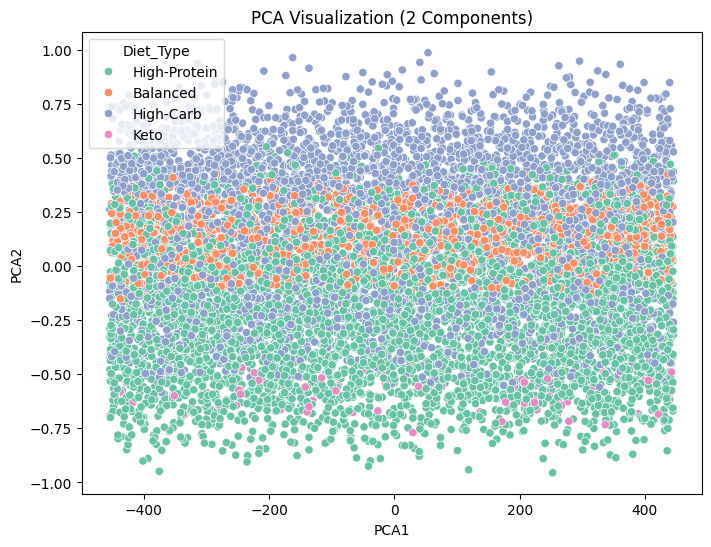

In [13]:
from sklearn.decomposition import PCA

# Keep 2 components for visualization
pca = PCA(n_components=2)
diet_pca_vis = pca.fit_transform(diet[numeric_features_all])

# Combine with original dataset for plotting
diet_final_vis = diet.copy()
diet_final_vis['PCA1'] = diet_pca_vis[:,0]
diet_final_vis['PCA2'] = diet_pca_vis[:,1]

# Plot PCA visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue=diet_clean['Diet_Type'], data=diet_final_vis, palette='Set2')
plt.title("PCA Visualization (2 Components)")
plt.show()


In [14]:
#Proximity Measures
from scipy.spatial.distance import pdist, squareform

# Select only numeric columns
diet_numeric = diet.select_dtypes(include=['int64', 'float64'])

# Compute distance matrices for the first 5 rows
euclidean_dist = squareform(pdist(diet_numeric.iloc[:5], metric='euclidean'))
manhattan_dist = squareform(pdist(diet_numeric.iloc[:5], metric='cityblock'))

# Cosine distance and convert to similarity
cos_dist = squareform(pdist(diet_numeric.iloc[:5], metric='cosine'))
cos_sim = 1 - cos_dist

# Print results
print("Euclidean Distance Matrix:\n", euclidean_dist)
print("\nManhattan Distance Matrix:\n", manhattan_dist)
print("\nCosine Similarity Matrix:\n", cos_sim)


Euclidean Distance Matrix:
 [[  0.          12.03805039 157.00339766  99.00657047   7.13826741]
 [ 12.03805039   0.         169.0054191   87.0064145    5.25645604]
 [157.00339766 169.0054191    0.         256.00138746 164.00290463]
 [ 99.00657047  87.0064145  256.00138746   0.          92.0083711 ]
 [  7.13826741   5.25645604 164.00290463  92.0083711    0.        ]]

Manhattan Distance Matrix:
 [[  0.          14.13647728 159.69401274 102.18183513  10.59077223]
 [ 14.13647728   0.         172.96585251  90.05217388   9.5621072 ]
 [159.69401274 172.96585251   0.         258.3051072  166.39437835]
 [102.18183513  90.05217388 258.3051072    0.          95.33136189]
 [ 10.59077223   9.5621072  166.39437835  95.33136189   0.        ]]

Cosine Similarity Matrix:
 [[1.         0.999998   0.99999792 0.99999605 0.99999562]
 [0.999998   1.         0.99999709 0.99999605 0.99999406]
 [0.99999792 0.99999709 1.         0.99999716 0.99999732]
 [0.99999605 0.99999605 0.99999716 1.         0.99999605]
 

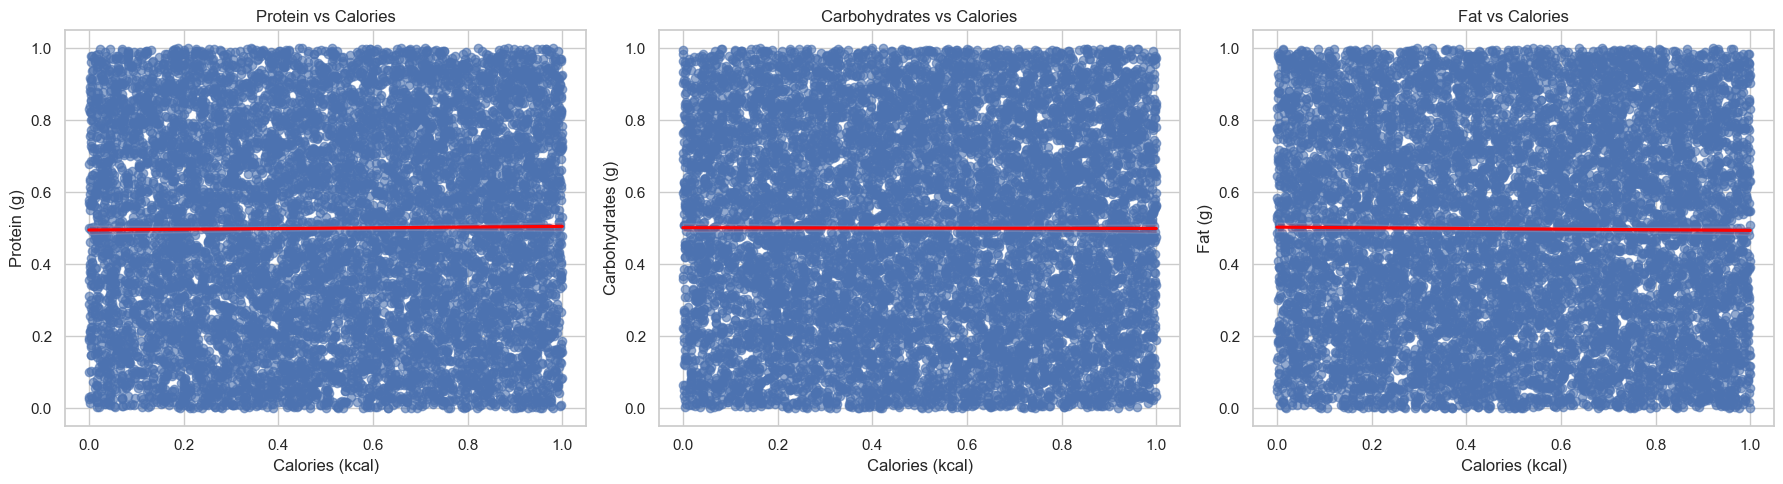

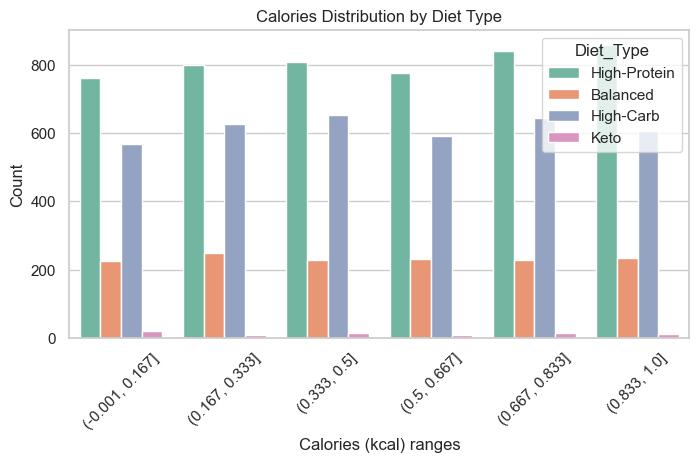

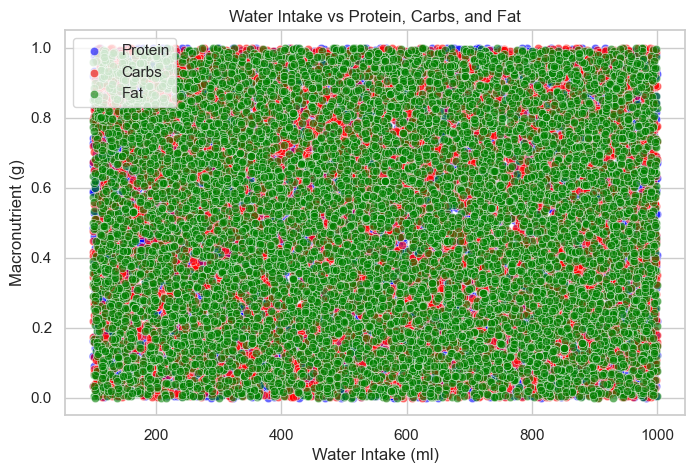

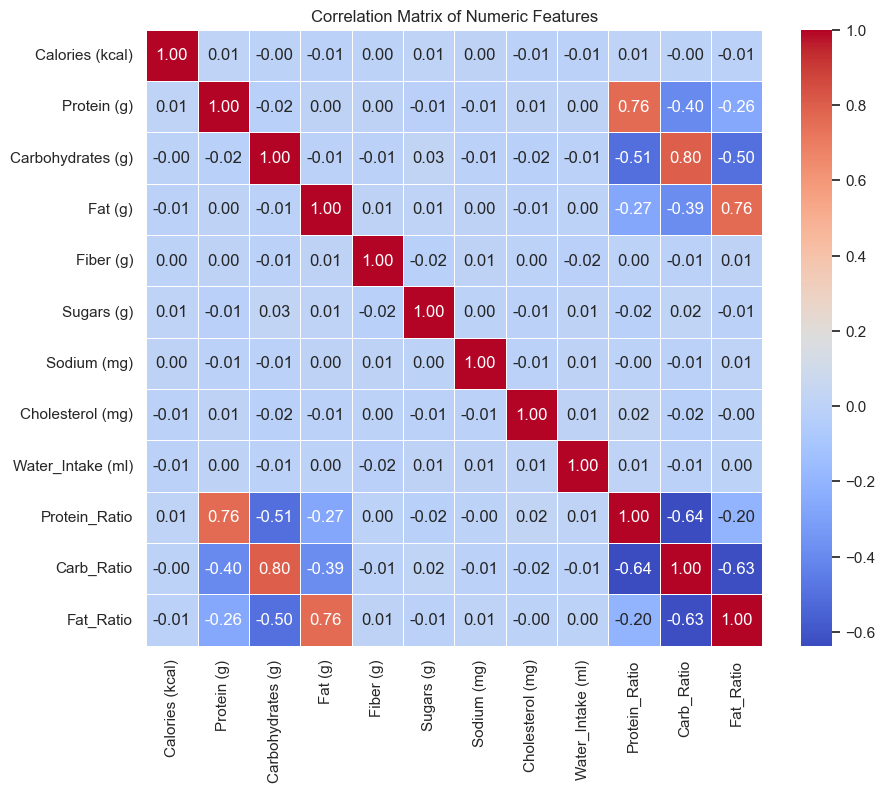

In [15]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set seaborn style
sns.set(style="whitegrid")

# Scatterplots with regression: Protein, Carbs, Fat vs Calories
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.regplot(x="Calories (kcal)", y="Protein (g)", data=diet, ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title("Protein vs Calories")
axes[0].set_xlabel("Calories (kcal)")
axes[0].set_ylabel("Protein (g)")

sns.regplot(x="Calories (kcal)", y="Carbohydrates (g)", data=diet, ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[1].set_title("Carbohydrates vs Calories")
axes[1].set_xlabel("Calories (kcal)")
axes[1].set_ylabel("Carbohydrates (g)")

sns.regplot(x="Calories (kcal)", y="Fat (g)", data=diet, ax=axes[2], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[2].set_title("Fat vs Calories")
axes[2].set_xlabel("Calories (kcal)")
axes[2].set_ylabel("Fat (g)")

plt.tight_layout()
plt.show()

# Countplot: Calories by Diet_Label (bin calories into ranges)
diet['Calories_bin'] = pd.cut(diet['Calories (kcal)'], bins=6)  # 6 ranges
plt.figure(figsize=(8,4))
sns.countplot(x="Calories_bin", hue="Diet_Type", data=diet, palette="Set2")
plt.xticks(rotation=45)
plt.title("Calories Distribution by Diet Type")
plt.xlabel("Calories (kcal) ranges")
plt.ylabel("Count")
plt.show()

# Dropping the temporary column
diet = diet.drop(columns=['Calories_bin'])


#Water Intake vs Macronutrients (Protein, Carbs, Fat)
plt.figure(figsize=(8,5))
sns.scatterplot(x="Water_Intake (ml)", y="Protein (g)", data=diet, alpha=0.6, label="Protein", color="blue")
sns.scatterplot(x="Water_Intake (ml)", y="Carbohydrates (g)", data=diet, alpha=0.6, label="Carbs", color="red")
sns.scatterplot(x="Water_Intake (ml)", y="Fat (g)", data=diet, alpha=0.6, label="Fat", color="green")
plt.title("Water Intake vs Protein, Carbs, and Fat")
plt.xlabel("Water Intake (ml)")
plt.ylabel("Macronutrient (g)")
plt.legend()
plt.show()

# Select numeric features
numeric_cols = diet.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [16]:
print("The Curated Dataset ready for training")
print(diet.shape)
diet

The Curated Dataset ready for training
(10000, 16)


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),Protein_Ratio,Carb_Ratio,Fat_Ratio,Diet_Type
0,Eggs,Meat,0.223636,0.844898,0.828421,0.010204,0.15,0.254,0.752,0.416667,Lunch,478,0.332288,0.655956,0.011755,High-Protein
1,Apple,Fruits,0.029091,0.779592,0.092632,0.044898,0.26,0.244,0.680,0.323333,Lunch,466,0.697509,0.245552,0.056940,High-Protein
2,Chicken Breast,Meat,0.320000,0.532653,0.780000,0.506122,0.32,0.894,0.295,0.523333,Breakfast,635,0.205303,0.599242,0.195455,Balanced
3,Banana,Fruits,0.120000,0.865306,0.443158,0.308163,0.65,0.882,0.307,0.043333,Snack,379,0.407129,0.441839,0.151032,High-Protein
4,Banana,Fruits,0.818182,0.671429,0.745263,0.938776,0.78,0.388,0.358,0.493333,Lunch,471,0.216337,0.483727,0.299936,Balanced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Salmon,Meat,0.538182,0.587755,0.532632,0.073469,0.17,0.010,0.976,0.290000,Breakfast,793,0.331111,0.617778,0.051111,High-Protein
9996,Grapes,Fruits,0.225455,0.446939,0.525263,0.634694,0.25,0.118,0.255,0.186667,Lunch,665,0.208371,0.499545,0.292084,Balanced
9997,Strawberry,Fruits,0.023636,0.724490,0.197895,0.420408,0.08,0.978,0.757,0.210000,Snack,876,0.445665,0.290598,0.263736,High-Protein
9998,Spinach,Vegetables,0.934545,0.514286,0.567368,0.222449,0.33,0.860,0.482,0.110000,Breakfast,319,0.270103,0.607216,0.122680,High-Protein


In [17]:
print(diet)

           Food_Item    Category  Calories (kcal)  Protein (g)  \
0               Eggs        Meat         0.223636     0.844898   
1              Apple      Fruits         0.029091     0.779592   
2     Chicken Breast        Meat         0.320000     0.532653   
3             Banana      Fruits         0.120000     0.865306   
4             Banana      Fruits         0.818182     0.671429   
...              ...         ...              ...          ...   
9995          Salmon        Meat         0.538182     0.587755   
9996          Grapes      Fruits         0.225455     0.446939   
9997      Strawberry      Fruits         0.023636     0.724490   
9998         Spinach  Vegetables         0.934545     0.514286   
9999          Banana      Fruits         0.712727     0.406122   

      Carbohydrates (g)   Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0              0.828421  0.010204       0.15       0.254        0.752   
1              0.092632  0.044898       0.26       0.244     

Accuracy: 0.999

Classification Report:
               precision    recall  f1-score   support

    Balanced       1.00      1.00      1.00       278
   High-Carb       1.00      1.00      1.00       738
High-Protein       1.00      1.00      1.00       969
        Keto       1.00      1.00      1.00        15

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



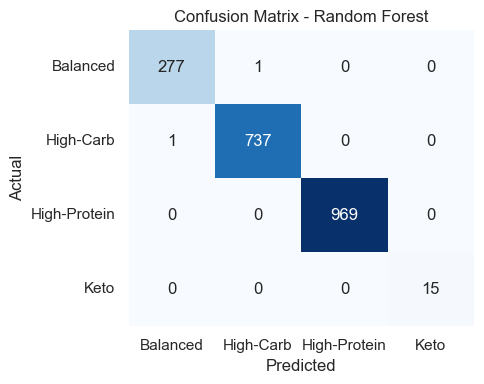

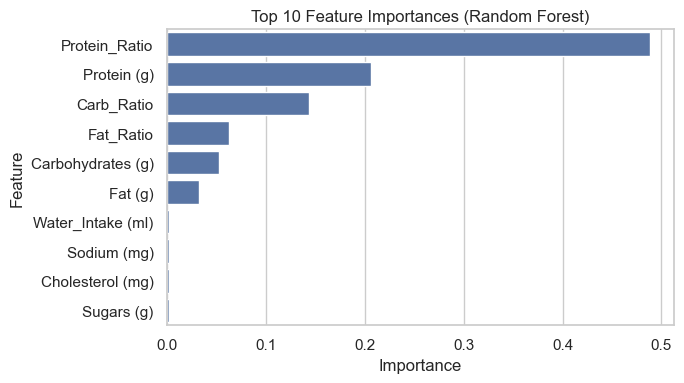

In [18]:
# VIII. Explanation on Data Mining Task carried
# Train a classifier to predict Diet_Type from numeric nutrition features.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Prepare features (X) and target (y)
# Use only numeric columns as model features; exclude the target.
numeric_cols = diet.select_dtypes(include=['number']).columns.tolist()
# Diet_Type is categorical; ensure it's not in X
X = diet[numeric_cols].copy()
y = diet['Diet_Type'].copy()

# 2) Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# 3) Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# 4) Train model (Random Forest)
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 5) Evaluate
y_pred = rf_model.predict(X_test)
print("Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# 6) Confusion Matrix (visual)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(pd.DataFrame(cm, index=le.classes_, columns=le.classes_), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# 7) Top feature importances (explainability)
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()


In [19]:
# Hybrid personalization utilities:
# - Compute BMI, BMR (Mifflin–St Jeor), TDEE
# - Map (optional) goal to a preferred diet type
# - Combine with model prediction to finalize diet type
# - Recommend food items from the dataset

def compute_bmi(weight_kg: float, height_cm: float) -> float:
    h_m = height_cm / 100.0
    return weight_kg / (h_m ** 2)

def compute_bmr_mifflin(weight_kg: float, height_cm: float, age: int, gender: str) -> float:
    # gender: "Male" or "Female"
    s = 5 if str(gender).lower().startswith('m') else -161
    return 10*weight_kg + 6.25*height_cm - 5*age + s

def activity_factor(level: str) -> float:
    levels = {
        "sedentary": 1.2,
        "light": 1.375,
        "moderate": 1.55,
        "active": 1.725,
        "very active": 1.9
    }
    return levels.get(str(level).lower(), 1.55)  # default "moderate"

def map_goal_to_diet(goal: str | None) -> str | None:
    if goal is None:
        return None
    g = str(goal).strip().lower()
    if "loss" in g or "cut" in g or "fat" in g:
        return "Keto"  # or "High-Protein"; choose one as primary
    if "gain" in g or "muscle" in g or "bulk" in g:
        return "High-Protein"
    if "endurance" in g or "athlete" in g or "cardio" in g:
        return "High-Carb"
    if "maintain" in g or "no" in g or "none" in g or "general" in g or "healthy" in g:
        return "Balanced"
    return None  # unknown → let model drive

def personalize_calories(tdee: float, goal: str | None) -> float:
    # Simple heuristic to adjust daily calories by goal (can be refined later)
    if goal is None:
        return tdee
    g = str(goal).lower()
    if "loss" in g:         # modest deficit ~15%
        return tdee * 0.85
    if "gain" in g:         # modest surplus ~15%
        return tdee * 1.15
    if "endurance" in g:    # slight surplus for training
        return tdee * 1.10
    # maintain / no specific goal
    return tdee


In [21]:
import pandas as pd
import numpy as np

def predict_user_diet_and_recommend(
    height_cm: float,
    weight_kg: float,
    age: int,
    gender: str,
    activity: str,
    goal: str | None,            # can be None or "No specific goal"
    n_recs: int = 6,
) -> dict:
    """
    1) Compute BMI, BMR, TDEE
    2) Estimate recommended daily calories based on goal
    3) Build a minimal feature row aligned with training X (numeric columns)
    4) Get model's predicted Diet_Type
    5) Reconcile with goal-based mapping (if provided, gently prefer goal)
    6) Recommend food items from that diet class
    """
    # 1) Personal metrics
    bmi = compute_bmi(weight_kg, height_cm)
    bmr = compute_bmr_mifflin(weight_kg, height_cm, age, gender)
    tdee = bmr * activity_factor(activity)
    rec_calories = personalize_calories(tdee, goal)

    # 2) Construct feature row for model prediction.
    # We'll create a synthetic row that has calories/macros ratios consistent with the goal,
    # but minimally we need to fill the numeric columns X used in training.
    # Here, we use calories as scaled proportion of dataset, and fallback zeros for unknowns.
    # (Optionally, you could ask the user for rough macros %; for now we rely on model generalization.)
    user_feat = pd.DataFrame([0]*len(X.columns), index=X.columns).T

    # Try to place calories if the column exists
    if "Calories (kcal)" in user_feat.columns:
        # Note: your dataset is scaled; rec_calories is absolute.
        # We map absolute calories to [0,1] by min-max using training data stats.
        # If X was already min-max scaled during your pipeline, this keeps it consistent.
        cal_min, cal_max = diet["Calories (kcal)"].min(), diet["Calories (kcal)"].max()
        # If your current 'Calories (kcal)' is already scaled [0,1], then this step is just a safe clamp.
        cal_scaled = (rec_calories - cal_min) / (cal_max - cal_min) if cal_max > cal_min else 0.5
        user_feat["Calories (kcal)"] = np.clip(cal_scaled, 0, 1)

    # If you have macro ratio columns, softly bias them based on goal → improves diet prediction.
    goal_pref = map_goal_to_diet(goal)
    if {"Protein_Ratio","Carb_Ratio","Fat_Ratio"}.issubset(user_feat.columns):
        # reasonable defaults (balanced)
        p_ratio, c_ratio, f_ratio = 0.20, 0.55, 0.25
        if goal_pref == "High-Protein":
            p_ratio, c_ratio, f_ratio = 0.35, 0.40, 0.25
        elif goal_pref == "Keto":
            p_ratio, c_ratio, f_ratio = 0.20, 0.10, 0.70
        elif goal_pref == "High-Carb":
            p_ratio, c_ratio, f_ratio = 0.15, 0.65, 0.20
        elif goal_pref == "Balanced" or goal_pref is None:
            p_ratio, c_ratio, f_ratio = 0.20, 0.55, 0.25

        user_feat["Protein_Ratio"] = p_ratio
        user_feat["Carb_Ratio"]    = c_ratio
        user_feat["Fat_Ratio"]     = f_ratio

    # 3) Predict diet type using model
    # Ensure column order matches training
    user_feat = user_feat.reindex(columns=X.columns, fill_value=0)
    pred_enc = rf_model.predict(user_feat)[0]
    model_diet = le.inverse_transform([pred_enc])[0]

    # 4) Reconcile with goal preference (soft override: if goal maps, prefer it)
    final_diet = goal_pref if goal_pref is not None else model_diet

    # 5) Recommend items from that diet type
    # Fallback to model_diet if goal_pref has no matching rows
    rec_pool = diet[diet["Diet_Type"] == final_diet]
    if rec_pool.empty:
        rec_pool = diet[diet["Diet_Type"] == model_diet]
    rec_items = (
        rec_pool["Food_Item"].dropna().sample(n=min(n_recs, len(rec_pool)), random_state=42).tolist()
        if not rec_pool.empty else []
    )

    # Build report
    return {
        "BMI": round(bmi, 2),
        "BMR_kcal": round(bmr, 0),
        "TDEE_kcal": round(tdee, 0),
        "Recommended_Daily_Calories": int(round(rec_calories, 0)),
        "Diet_Type_Model": model_diet,
        "Diet_Type_Final": final_diet,
        "Food_Recommendations": rec_items
    }

# Real-Time User Interaction – Personalized Diet Recommendation

print("------ Personalized Diet Recommendation System ------\n")

#Take user inputs
try:
    height_cm = float(input("Enter your height (in cm): "))
    weight_kg = float(input("Enter your weight (in kg): "))
    age = int(input("Enter your age (in years): "))
    gender = input("Enter your gender (Male/Female): ").strip().capitalize()

    print("\nSelect your activity level:")
    print("1. Sedentary (little to no exercise)")
    print("2. Light (1-3 days/week)")
    print("3. Moderate (3-5 days/week)")
    print("4. Active (6-7 days/week)")
    print("5. Very Active (intense exercise daily)")
    act_choice = input("Enter choice (1-5): ").strip()

    activity_levels = {
        "1": "Sedentary",
        "2": "Light",
        "3": "Moderate",
        "4": "Active",
        "5": "Very Active"
    }
    activity = activity_levels.get(act_choice, "Moderate")

    print("\nSelect your goal (or press Enter for no specific goal):")
    print("1. Weight Loss")
    print("2. Muscle Gain")
    print("3. Endurance")
    print("4. Maintain")
    print("5. No specific goal")
    goal_choice = input("Enter choice (1-5): ").strip()

    goals = {
        "1": "Weight Loss",
        "2": "Muscle Gain",
        "3": "Endurance",
        "4": "Maintain",
        "5": None
    }
    goal = goals.get(goal_choice, None)

except Exception as e:
    print(" Invalid input, please try again:", e)
    raise SystemExit

#Predict using the hybrid model
result = predict_user_diet_and_recommend(
    height_cm=height_cm,
    weight_kg=weight_kg,
    age=age,
    gender=gender,
    activity=activity,
    goal=goal,
    n_recs=6
)

#Display results neatly
print("\n\n------ Personalized Diet Plan Summary ------")
print(f" Gender: {gender}")
print(f" Height: {height_cm} cm   Weight: {weight_kg} kg   Age: {age}")
print(f" Activity Level: {activity}")
if goal: print(f" Goal: {goal}")
else: print(f" Goal: None specified (general wellness)")

print("\n Health Metrics:")
print(f"   BMI: {result['BMI']} kg/m²")
print(f"   BMR: {result['BMR_kcal']} kcal/day")
print(f"   TDEE: {result['TDEE_kcal']} kcal/day")
print(f"   Recommended Daily Calories: {result['Recommended_Daily_Calories']} kcal/day")

print("\n Diet Recommendation:")
print(f"  Model-predicted diet: {result['Diet_Type_Model']}")
print(f"  Final recommended diet (goal-adjusted): {result['Diet_Type_Final']}")

print("\n Suggested Food Items:")
for i, food in enumerate(result['Food_Recommendations'], 1):
    print(f"   {i}. {food}")

print("\n End of personalized report.\n")



------ Personalized Diet Recommendation System ------



Enter your height (in cm):  170
Enter your weight (in kg):  86
Enter your age (in years):  20
Enter your gender (Male/Female):  Male



Select your activity level:
1. Sedentary (little to no exercise)
2. Light (1-3 days/week)
3. Moderate (3-5 days/week)
4. Active (6-7 days/week)
5. Very Active (intense exercise daily)


Enter choice (1-5):  3



Select your goal (or press Enter for no specific goal):
1. Weight Loss
2. Muscle Gain
3. Endurance
4. Maintain
5. No specific goal


Enter choice (1-5):  4




------ Personalized Diet Plan Summary ------
 Gender: Male
 Height: 170.0 cm   Weight: 86.0 kg   Age: 20
 Activity Level: Moderate
 Goal: Maintain

 Health Metrics:
   BMI: 29.76 kg/m²
   BMR: 1828.0 kcal/day
   TDEE: 2833.0 kcal/day
   Recommended Daily Calories: 2833 kcal/day

 Diet Recommendation:
  Model-predicted diet: Balanced
  Final recommended diet (goal-adjusted): Balanced

 Suggested Food Items:
   1. Milkshake
   2. Oats
   3. Milk
   4. Yogurt
   5. Orange Juice
   6. Paneer

 End of personalized report.

